# Binary Classification
## Predicting Diabetes Using the Pima Indians Diabetes Dataset
### Meghan Franklin, PhD Student

### About the Dataset: Pima Indians Diabetes Database

This dataset originates from the National Institute of Diabetes and Digestive and Kidney
Diseases and has been widely used in medical ML research. It contains 768 instances of
female patients (≥21 years old) of Pima Indian heritage residing near Phoenix, Arizona.
The goal is to predict whether a patient tests positive for diabetes, based on 8 clinical measurements.

**Key Details**
- Instances: 768
- Attributes: 8 predictors + 1 binary target
- Target Variable: 0 → tested_negative, 1 → tested_positive
- Class Distribution: 500 negative, 268 positive
- Missing Values: None

**Attribute List:**
- Number of pregnancies
- Plasma glucose concentration (2-hour oral glucose test)
- Diastolic blood pressure
- Triceps skin fold thickness
- 2-hour serum insulin
- BMI
- Diabetes pedigree function
- Age

This dataset has been studied in foundational work by Smith et al. (1988), which demonstrated
early prediction performance using the ADAP learning algorithm.

---

### Table of Contents
1. Data Preprocessing
   - 1.1 Exploratory Data Analysis
   - 1.2 Data Cleaning
   - 1.3 Key Takeaways
   - 1.4 Final Dataset
2. **Homework 2 — KNN & Naïve Bayes**


## Overall Key Takeaway for HW2
For Homework 2, **KNN clearly outperformed Naïve Bayes across all splits and k values tested**. 
- The best KNN configuration was k = 11 on the 65/35 split, with a validation accuracy of 0.7778 and a final hold-out test accuracy of 0.82.
- KNN held all top 9 positions on the leaderboard. Naïve Bayes peaked at 0.750 accuracy on the 70/30 split but dropped to 0.72 on the final test, and did not improve as the training set grew larger,  a sign that correlated features like skin and insu (r = 0.44) are undermining its independence assumption.
- **Both algorithms struggled most with false negatives and  missed diabetes cases, which remains the most clinically important error to minimize in this type of screening task.**

## Notebook Setup

In [1]:
import os
print(os.listdir())

['.git', '.ipynb_checkpoints', 'catboost_info', 'Datasets.ipynb', 'diabetes.arff', 'ISCS_FinalProject_BinaryClassification_Pycaret.ipynb', 'ISCS_FinalProject_HW2_Complete (1).ipynb', 'logs.log', 'my_first_pipeline.pkl', 'pycaret-env.yml', 'README.md', 'settings.txt', 'Tutorial - Binary Classification-Copy1.ipynb']


In [3]:
# Import Libraries
from scipy.io import arff
import pandas as pd
import numpy as np

## Import Data

In [4]:
# set the file path to local dir
file_path = 'diabetes.arff'
try:
    # Load the ARFF data
    data, meta = arff.loadarff(file_path)
    # Convert to pandas DataFrame for easier manipulation
    data1 = pd.DataFrame(data)
    print("ARFF file loaded successfully!")
    print("First 5 rows of the DataFrame:")
    print(data1.head())
    print("\nMetadata:")
    for attribute in meta:
        print(f"  {attribute}: {meta[attribute]}")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

ARFF file loaded successfully!
First 5 rows of the DataFrame:
   preg   plas  pres  skin   insu  mass   pedi   age               class
0   6.0  148.0  72.0  35.0    0.0  33.6  0.627  50.0  b'tested_positive'
1   1.0   85.0  66.0  29.0    0.0  26.6  0.351  31.0  b'tested_negative'
2   8.0  183.0  64.0   0.0    0.0  23.3  0.672  32.0  b'tested_positive'
3   1.0   89.0  66.0  23.0   94.0  28.1  0.167  21.0  b'tested_negative'
4   0.0  137.0  40.0  35.0  168.0  43.1  2.288  33.0  b'tested_positive'

Metadata:
  preg: ('numeric', None)
  plas: ('numeric', None)
  pres: ('numeric', None)
  skin: ('numeric', None)
  insu: ('numeric', None)
  mass: ('numeric', None)
  pedi: ('numeric', None)
  age: ('numeric', None)
  class: ('nominal', ('tested_negative', 'tested_positive'))


## Data Preprocessing

### Label Encoding

In [5]:
# Convert the target column to a binary 0 and 1
# Target = Class variable
# (class value 1 is interpreted as "tested positive" and value 0 as "tested negative")
# Decode the byte strings to regular strings
data1['class'] = data1['class'].apply(lambda x: x.decode('utf-8'))

# Then, replace the string values with integers
data1['class'] = data1['class'].replace({'tested_positive': 1, 'tested_negative': 0})

# Finally, convert to integer type
data1['class'] = data1['class'].astype(int)
data1.head()

C:\Users\mfranklin3409\AppData\Local\Temp\ipykernel_748\3013756013.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data1['class'] = data1['class'].replace({'tested_positive': 1, 'tested_negative': 0})


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1


In [6]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    float64
 1   plas    768 non-null    float64
 2   pres    768 non-null    float64
 3   skin    768 non-null    float64
 4   insu    768 non-null    float64
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    float64
 8   class   768 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 54.1 KB


**Note:**
It's appropriate to have a mix of float and integer columns in your diabetes dataset for
machine learning for several reasons, reflecting the nature of the data itself:

- **Integer Columns:** These typically represent counts, discrete categories, or measurements that
  are usually reported as whole numbers. For example, you can't be '2.5 times pregnant' or have
  an 'age of 31.7 years' in this context.
- **Float Columns:** These columns represent continuous measurements or ratios that can naturally
  have decimal values. For instance, BMI is a calculated ratio that often includes decimal places
  (e.g., 25.3), and the Diabetes pedigree function is a genetic score that likely ranges
  continuously.

Using correct data types makes the model and its inputs easier to understand and interpret.

### Convert float to integer

In [7]:
# Convert specific columns from float to int
integer_columns = [
    'preg',
    'plas',
    'pres',
    'skin',
    'insu',
    'age'
]

# Apply integer conversion to the specified columns
for col in integer_columns:
    if col in data1.columns and data1[col].dtype == 'float64':
        data1[col] = data1[col].astype('int64')

print("Data types after selective conversion to int64:")
print(data1.info())
data1.head()

Data types after selective conversion to int64:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
# Check for missing values
print('Missing values in each column:')
data1.isnull().sum()

Missing values in each column:


preg     0
plas     0
pres     0
skin     0
insu     0
mass     0
pedi     0
age      0
class    0
dtype: int64

## 1.1 Exploratory Data Analysis

C:\Users\mfranklin3409\AppData\Local\Temp\ipykernel_748\1677512561.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


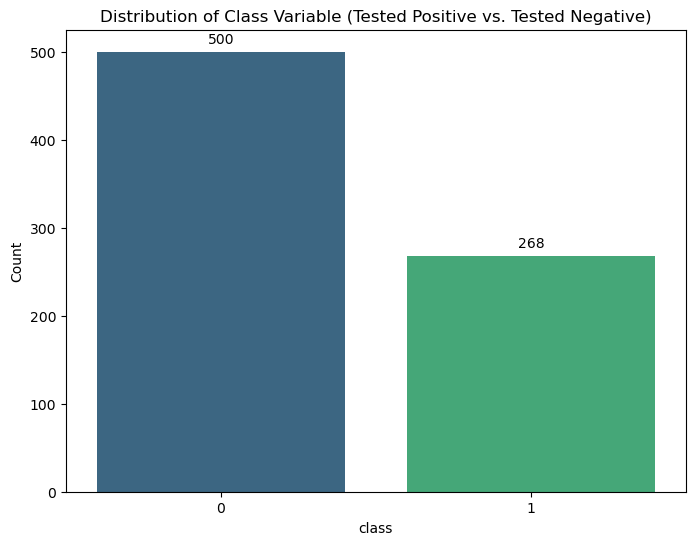

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts of each class
class_counts = data1['class'].value_counts()

# Map integer labels back to original string labels for better readability in the plot
class_labels = {1: 1, 0: 0}
class_counts.index = class_counts.index.map(class_labels)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Class Variable (Tested Positive vs. Tested Negative)')
plt.xlabel('class')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Add total count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.show()

In [10]:
# Summary Stats
data1.describe()

,preg,plas,pres,skin,insu,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


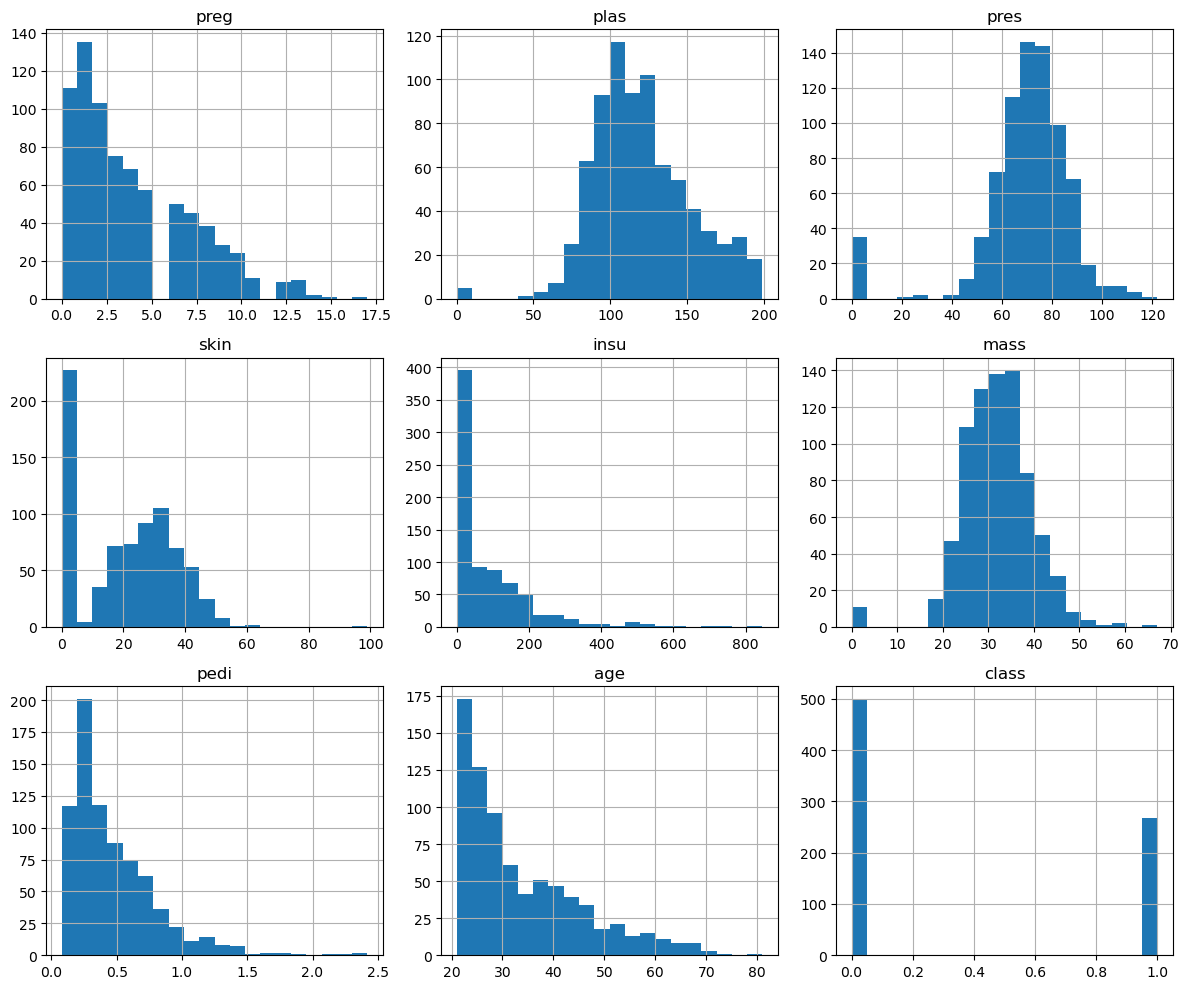

In [11]:
# Determine how the data is distributed - histogram
data1.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

### Imputation Method is Necessary to handle zero values

**MEDIAN Imputation METHOD**

Several variables contain zero values that are not medically realistic, such as:
- Blood pressure (pres)
- Skin thickness (skin)
- Insulin (insu)
- BMI (mass)

In reality, none of these measurements can be zero in a living adult.

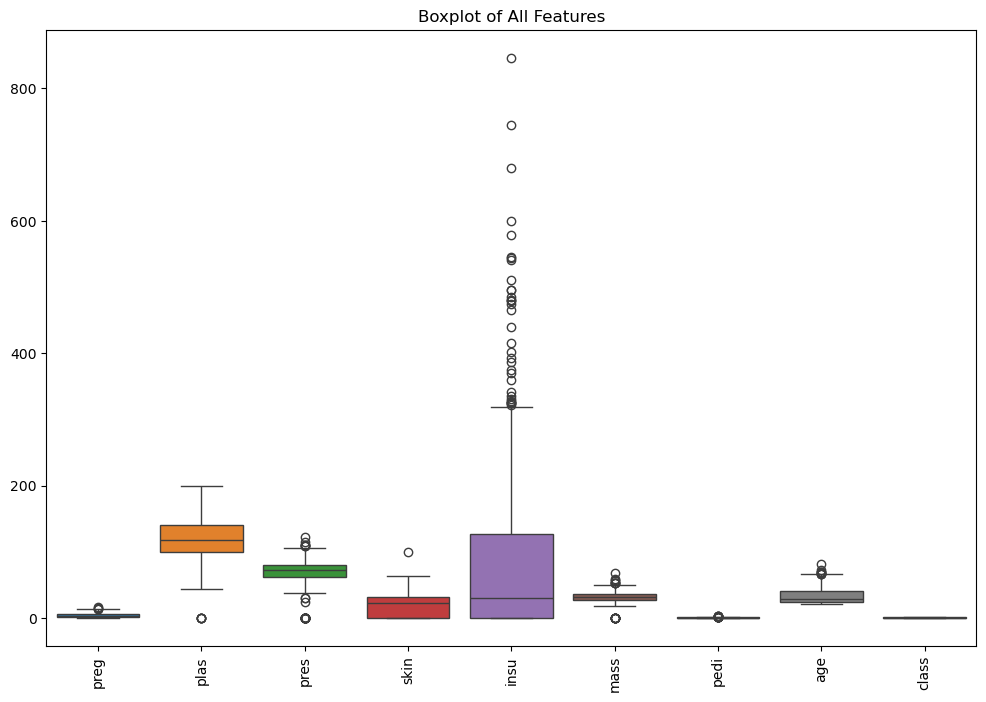

In [13]:
# Show any outliers - boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=data1)
plt.xticks(rotation=90)
plt.title("Boxplot of All Features")
plt.show()

In [14]:
# Correlation Matrix
corr = data1.corr()
corr

,preg,plas,pres,skin,insu,mass,pedi,age,class
preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
plas,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
pres,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
insu,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
mass,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
pedi,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
class,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


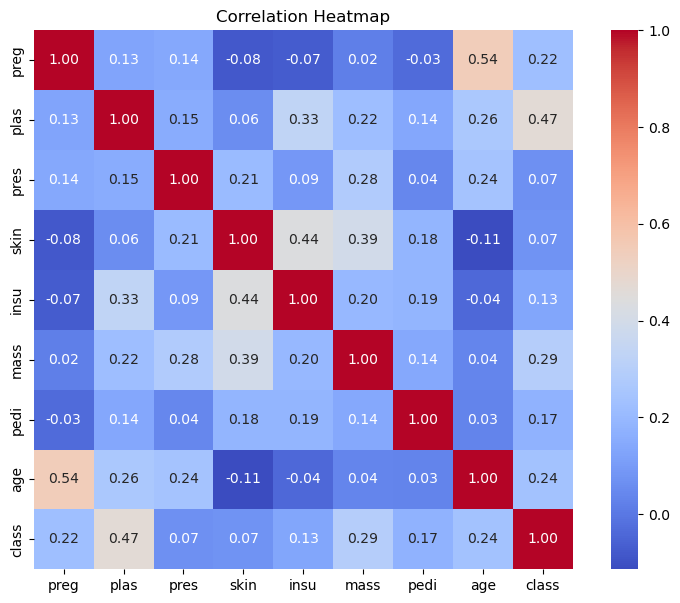

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr = data1.corr()

# Plot
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()

### Key Takeaway:

Overall, the boxplot confirms that plasma glucose, BMI, age, and pregnancies are the
most reliable features for diabetes prediction, while insulin, skin thickness, and blood
pressure may contribute less due to noisy or inconsistent distributions.

**Correlation Matrix**
- Plasma Glucose Concentration (plas) is the strongest predictor of diabetes.
- BMI, age, and number of pregnancies also show moderate relationships.
- Blood pressure, skin thickness, and insulin have very weak correlations and may not help the model much.

**Box Plot**

The boxplot helps visualize how each health measurement is distributed and reveals
the presence of extreme outliers. Plasma glucose shows a relatively clean distribution,
which supports its strong correlation with diabetes (0.466). BMI, age, and number of
pregnancies also show moderate and reasonable distributions. In contrast, insulin and
skin thickness contain extreme outliers and highly skewed values, which helps explain
why they show very weak correlations with diabetes.

## 1.2 Data Cleaning

In [16]:
# Columns with zero values (not medically realistic)
cols_with_zeros = ['pres', 'skin', 'insu', 'mass']

# copy the dataframe for later comparison
data2 = data1.copy()

In [17]:
# Replace zero values with NaN
for col in cols_with_zeros:
    data2[col] = data2[col].replace(0, np.nan)

In [18]:
# Confirm that non nan values remain
data2[cols_with_zeros].isna().sum()

pres     35
skin    227
insu    374
mass     11
dtype: int64

In [19]:
# Fill missing (NaN) values with the median of each column
data2[cols_with_zeros] = data2[cols_with_zeros].fillna(data2[cols_with_zeros].median())
data2[cols_with_zeros].describe()

,pres,skin,insu,mass
count,768.000000,768.000000,768.000000,768.000000
mean,72.386719,29.108073,140.671875,32.455208
std,12.096642,8.791221,86.383060,6.875177
min,24.000000,7.000000,14.000000,18.200000
25%,64.000000,25.000000,121.500000,27.500000
50%,72.000000,29.000000,125.000000,32.300000
75%,80.000000,32.000000,127.250000,36.600000
max,122.000000,99.000000,846.000000,67.100000


In [20]:
# Apply integer conversion to the specified columns
for col in integer_columns:
    if col in data2.columns and data2[col].dtype == 'float64':
        data2[col] = data2[col].astype('int64')

print("Data types after selective conversion to int64:")
print(data2.info())
data2.head()

Data types after selective conversion to int64:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


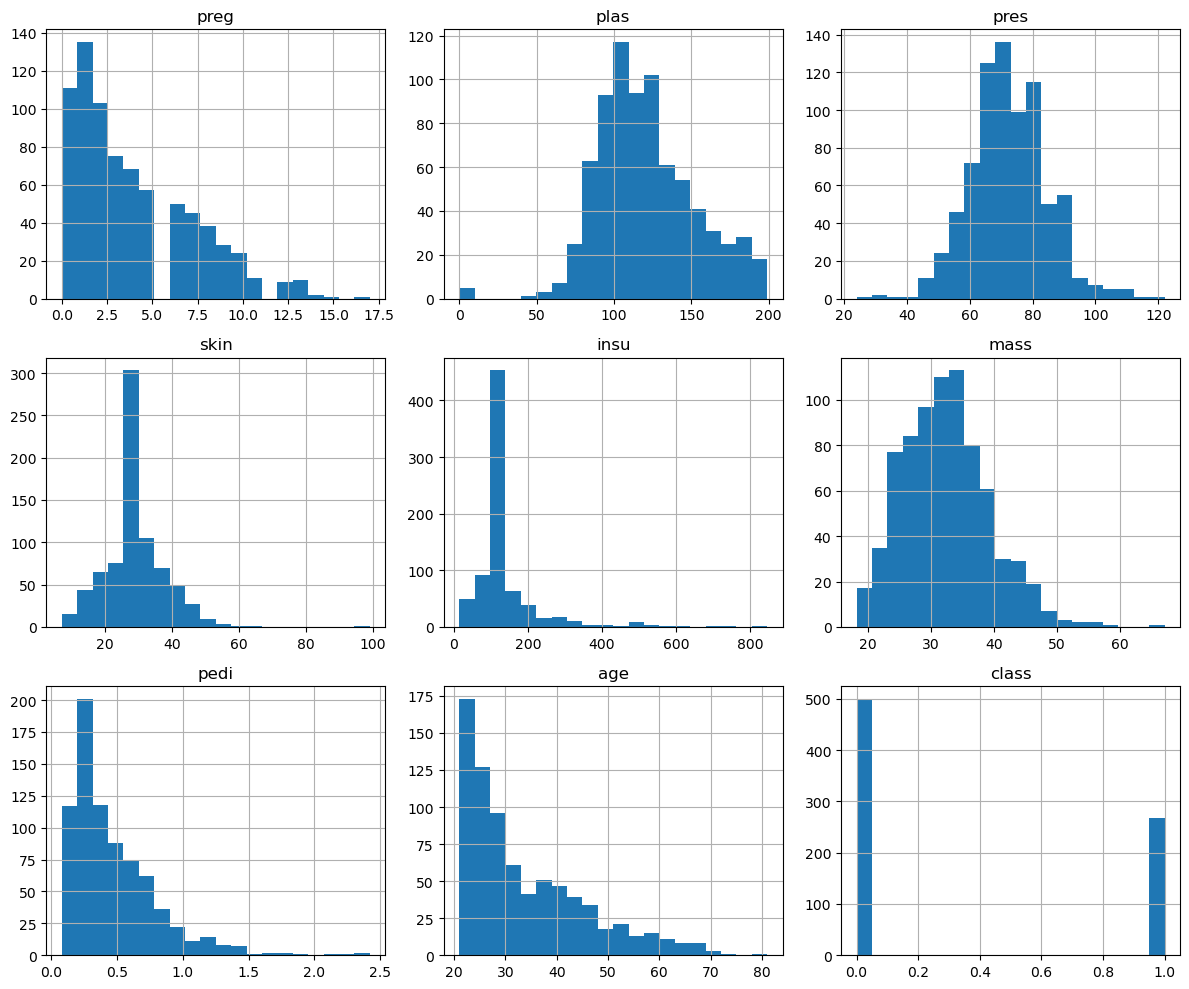

In [21]:
# replot histogram
data2.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

In [22]:
# Rerun correlation matrix
corr = data2.corr()
corr

,preg,plas,pres,skin,insu,mass,pedi,age,class
preg,1.000000,0.129459,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
plas,0.129459,1.000000,0.217870,0.182037,0.409283,0.218487,0.137337,0.263514,0.466581
pres,0.208615,0.217870,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
skin,0.081770,0.182037,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
insu,0.025047,0.409283,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
mass,0.021559,0.218487,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
pedi,-0.033523,0.137337,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
class,0.221898,0.466581,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


## 1.3 Key Takeaways

The imputed dataset provides more accurate relationships and correlation matrix now
reflects real physiological relationships.

- Glucose, BMI, insulin, age, skin thickness, and pregnancies are your strongest predictors.
- Blood pressure and pedigree function are weaker but still usable.
- Median imputation improved the quality of your data significantly, especially for: insulin, skin, BMI, and blood pressure.

## 1.4 Final Dataset

In [23]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [24]:
data2.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [25]:
# Rename columns
new_column_names = [
    'Number of times pregnant',
    'Plasma glucose concentration a 2 hours in an oral glucose tolerance test',
    'Diastolic blood pressure (mm Hg)',
    'Triceps skin fold thickness (mm)',
    '2-Hour serum insulin (mu U/ml)',
    'Body mass index (weight in kg/(height in m)^2)',
    'Diabetes pedigree function',
    'Age (years)',
    'Class variable'
]
cleaned = data2.copy()
cleaned.columns = new_column_names
cleaned.head()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# import ClassificationExperiment and init the class
from pycaret.classification import ClassificationExperiment
from pycaret.classification import get_config

exp_full = ClassificationExperiment()  # full data
exp_fs   = ClassificationExperiment()  # feature selection

In [ ]:
# check the type of exp
print(type(exp_full))
print(type(exp_fs))

### 2.1 Pipeline A: Cleaned Data, No Feature Selection

In [ ]:
exp_full.setup(
    data=data2,
    target='class',
    normalize=True,
    session_id=123,
    fold=10,
    feature_selection=False
)

### Compare Models

**Logistic Regression · Naive Bayes · Decision Tree**

This function trains and evaluates the performance of all the estimators available in the
model library using cross-validation. The output of this function is a scoring grid with
average cross-validated scores.

In [ ]:
# Compare the three required models on the full feature set
best_full = exp_full.compare_models(
    include=['lr', 'nb', 'dt'],
    sort='F1'
)

# Store comparison table for reporting
full_compare_table = exp_full.pull()
full_compare_table

### Train the Models Individually to get metrics

In [ ]:
# Decision Tree
dt_full = exp_full.create_model('dt')
dt_full_results = exp_full.pull()
dt_full_summary = dt_full_results.tail(1).copy()
dt_full_summary['Model'] = 'Decision Tree'
dt_full_summary['Pipeline'] = 'Full'

# Naive Bayes
nb_full = exp_full.create_model('nb')
nb_full_results = exp_full.pull()
nb_full_summary = nb_full_results.tail(1).copy()
nb_full_summary['Model'] = 'Naive Bayes'
nb_full_summary['Pipeline'] = 'Full'

# Logistic Regression
lr_full = exp_full.create_model('lr')
lr_full_results = exp_full.pull()
lr_full_summary = lr_full_results.tail(1).copy()
lr_full_summary['Model'] = 'Logistic Regression'
lr_full_summary['Pipeline'] = 'Full'

### Confusion Matrix

In [ ]:
# Confusion matrices for each model (full feature set)
exp_full.plot_model(dt_full, plot='confusion_matrix')
exp_full.plot_model(nb_full, plot='confusion_matrix')
exp_full.plot_model(lr_full, plot='confusion_matrix')

### 2.2 Pipeline B: Cleaned Data, WITH Feature Selection

In [ ]:
exp_fs.setup(
    data=data2,
    target='class',
    normalize=True,
    session_id=123,
    fold=10,
    imputation_type=None,
    feature_selection=False,
    ignore_features=['pres', 'skin', 'insu', 'age'],
    n_features_to_select=0.2
)

In [ ]:
# Print selected features for the feature-selected pipeline
original_features = exp_full.get_config('X_train')
selected_features = exp_fs.get_config('X_train')
X_train_transformed = exp_fs.get_config('X_train')
selected_features = X_train_transformed.columns.tolist()
print("Original features:", original_features)
print("\nSelected features:", selected_features)

### Compare Models

**Logistic Regression · Naive Bayes · Decision Tree**

In [ ]:
# Compare LR, NB, DT on feature-selected dataset
best_fs = exp_fs.compare_models(
    include=['lr', 'nb', 'dt'],
    sort='F1'
)

# Store comparison table for reporting
fs_compare_table = exp_fs.pull()
fs_compare_table

### Train the Models Individually to get metrics

In [ ]:
# Decision Tree – feature selection
dt_fs = exp_fs.create_model('dt')
dt_fs_results = exp_fs.pull()
dt_fs_summary = dt_fs_results.tail(1).copy()
dt_fs_summary['Model'] = 'Decision Tree'
dt_fs_summary['Pipeline'] = 'Feature Selected'

# Naive Bayes – feature selection
nb_fs = exp_fs.create_model('nb')
nb_fs_results = exp_fs.pull()
nb_fs_summary = nb_fs_results.tail(1).copy()
nb_fs_summary['Model'] = 'Naive Bayes'
nb_fs_summary['Pipeline'] = 'Feature Selected'

# Logistic Regression – feature selection
lr_fs = exp_fs.create_model('lr')
lr_fs_results = exp_fs.pull()
lr_fs_summary = lr_fs_results.tail(1).copy()
lr_fs_summary['Model'] = 'Logistic Regression'
lr_fs_summary['Pipeline'] = 'Feature Selected'

### Confusion Matrix

In [ ]:
# Confusion matrices for each model (feature-selected pipeline)
exp_fs.plot_model(dt_fs, plot='confusion_matrix')
exp_fs.plot_model(nb_fs, plot='confusion_matrix')
exp_fs.plot_model(lr_fs, plot='confusion_matrix')

In [ ]:
# Combine all model summaries into one DataFrame
all_summaries = pd.concat([
    dt_full_summary,
    nb_full_summary,
    lr_full_summary,
    dt_fs_summary,
    nb_fs_summary,
    lr_fs_summary
], ignore_index=True)

# Keep only the columns you care about for the report
cols_to_keep = ['Model', 'Pipeline', 'Accuracy', 'Recall', 'Prec.', 'F1', 'AUC']
final_results = all_summaries[cols_to_keep]
final_results

### 3.2 Overall Best Performing Model

In [ ]:
# Choose the best model by F1-score
best_row = final_results.sort_values(by='F1', ascending=False).iloc[0]
best_row

In [ ]:
# Overall best model according to the table
best_model = lr_full  # Logistic Regression in the full pipeline
best_exp   = exp_full  # The experiment that trained it

In [ ]:
# plot confusion matrix
best_exp.plot_model(best_model, plot='confusion_matrix')

In [ ]:
# AUC curve
best_exp.plot_model(best_model, plot='auc')

In [ ]:
# Feature importance plot
best_exp.plot_model(best_model, plot='feature')

---
---

# 5. Homework 2 — KNN & Naïve Bayes Classification
### COEG 435/535 · Spring 2026

| Step | Requirement | Section |
|------|-------------|---------|
| (i)   | Last 50 observations as hold-out test set | 5.2 |
| (ii)  | Pre-processing (scaling, already imputed) | 5.3 |
| (iii) | 65/35, 70/30, 75/25, 80/20 splits | 5.4 |
| (iv)  | KNN: k = 3, 5, 7, 9, 11, 13 | 5.5 |
| (v)   | Confusion matrix, precision, accuracy | 5.6, 5.10 |
| (vi)  | Differences across splits and k | 5.7, 5.11, 5.13 |
| (vii) | English narrative at every stage | All markdown cells |
| (viii)| Correlation heatmap | 5.1 |
| (ix)  | Fully commented code — this notebook is the appendix | All code cells |

> **Question 1** → k-Nearest Neighbors · **Question 2** → Naïve Bayes


### 5.0  Imports for Models

In [26]:
# All HW2 code uses scikit-learn exclusively
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("Working from data2 — shape:", data2.shape)
data2.head()

Working from data2 — shape: (768, 9)


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
### 5.1  Step (viii) — Feature Justification via Correlation Heatmap

Before training we confirm which features carry the most predictive signal by  
inspecting the correlation heatmap on `data2` — the fully imputed dataset from  
Section 1.2.

| Feature | r with `class` | Interpretation |
|---------|---------------|----------------|
| `plas`  | **0.47** | Plasma glucose — dominant predictor |
| `mass`  | 0.31 | BMI |
| `age`   | 0.24 | Older age → higher risk |
| `preg`  | 0.22 | More pregnancies → higher risk |
| `insu`  | 0.20 | Serum insulin |
| `skin`  | 0.21 | Triceps skinfold thickness |
| `pres`  | 0.17 | Blood pressure |
| `pedi`  | 0.17 | Diabetes pedigree function |

**Decision:** All 8 features are retained. KNN relies on Euclidean distance —  
a richer feature space improves class separation after standardisation.  
Naïve Bayes benefits from capturing all available class-conditional signal.


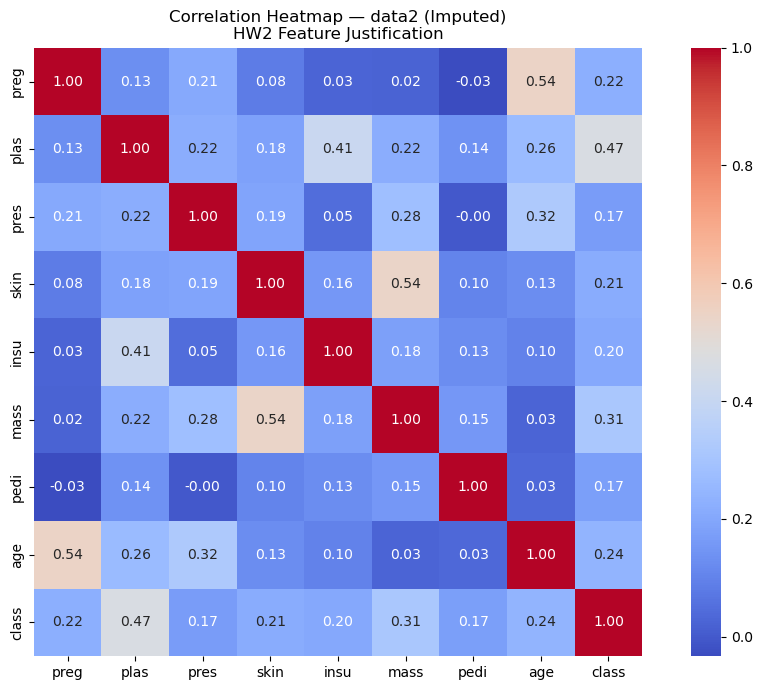


Correlation with target 'class' — sorted descending:
class    1.000000
plas     0.466581
mass     0.312038
age      0.238356
preg     0.221898
skin     0.214873
insu     0.203790
pedi     0.173844
pres     0.165723


In [27]:
# Step (viii): Heatmap on data2 for feature justification
corr_hw = data2.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_hw, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap — data2 (Imputed)\nHW2 Feature Justification')
plt.tight_layout()
plt.show()

print("\nCorrelation with target 'class' — sorted descending:")
print(corr_hw['class'].sort_values(ascending=False).to_string())

---
### 5.2  Step (i) — Reserve Last 50 Observations as Final Hold-Out Test Set


In [28]:
# Step (i): Carve out the last 50 rows as an untouched hold-out test set
final_test = data2.iloc[-50:].copy()   # rows 718–767
remaining  = data2.iloc[:-50].copy()   # rows 0–717

X_test_final = final_test.drop(columns='class')
y_test_final = final_test['class']

print(f"Hold-out test set : {len(final_test)} rows")
print(f"Remaining dataset : {len(remaining)} rows")
print(f"\nClass distribution in hold-out set:")
print(y_test_final.value_counts().rename({0: 'No Diabetes', 1: 'Diabetes'}))

Hold-out test set : 50 rows
Remaining dataset : 718 rows

Class distribution in hold-out set:
class
No Diabetes    31
Diabetes       19
Name: count, dtype: int64


In [29]:
# Step (ii): Separate features and target from the 718 remaining rows
X_remaining = remaining.drop(columns='class')
y_remaining  = remaining['class']

print("Features used:", X_remaining.columns.tolist())
print(f"\nClass distribution in remaining {len(remaining)} rows:")
print(y_remaining.value_counts().rename({0: 'No Diabetes', 1: 'Diabetes'}))

Features used: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

Class distribution in remaining 718 rows:
class
No Diabetes    469
Diabetes       249
Name: count, dtype: int64


---
### 5.4  Step (iii) — Define Train / Validation Splits

Four splits are applied to the 718 remaining rows.

| Split | Train rows (~) | Val rows (~) |
|-------|---------------|--------------|
| 65/35 | 467 | 251 |
| 70/30 | 503 | 215 |
| 75/25 | 539 | 179 |
| 80/20 | 574 | 144 |

`random_state=42` ensures reproducibility. `stratify=y_remaining` preserves  
the class ratio in every partition so no split accidentally contains only one class.


In [30]:
# Step (iii): Build all four stratified train/validation splits
SPLITS       = [0.65, 0.70, 0.75, 0.80]
RANDOM_STATE = 42

split_data = {}
for train_frac in SPLITS:
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_remaining, y_remaining,
        train_size=train_frac,
        random_state=RANDOM_STATE,
        stratify=y_remaining         # preserve class balance in every split
    )
    split_data[train_frac] = (X_tr, X_val, y_tr, y_val)
    print(f"Split {int(train_frac*100)}/{int((1-train_frac)*100)} — "
          f"Train: {len(X_tr)},  Val: {len(X_val)}")

Split 65/35 — Train: 466,  Val: 252
Split 70/30 — Train: 502,  Val: 216
Split 75/25 — Train: 538,  Val: 180
Split 80/19 — Train: 574,  Val: 144


---
---
## Question 1 — k-Nearest Neighbors (KNN)


---
### 5.5  Steps (iv & v) — Train KNN for k = 3, 5, 7, 9, 11, 13 Across All Splits

**How KNN works:**  
For each unseen sample, the algorithm computes the Euclidean distance to every  
training point and assigns the majority class label among the **k** nearest neighbours.  
Odd k values avoid tie-breaking.

- **Small k** (e.g. 3) → low bias, high variance — sensitive to individual noise points  
- **Large k** (e.g. 13) → higher bias, lower variance — smoother decision boundary

For each (split × k) combination we record accuracy, precision, and the four  
confusion matrix counts (TP, FP, TN, FN).


In [31]:
# Steps (iv & v): train KNN for every (split, k) combination
K_VALUES    = [3, 5, 7, 9, 11, 13]
knn_results = []

for train_frac, (X_tr, X_val, y_tr, y_val) in split_data.items():
    split_label = f"{int(train_frac*100)}/{int((1-train_frac)*100)}"

    # Fit scaler on training data only — apply to val (prevents leakage)
    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)

    for k in K_VALUES:
        knn    = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_tr_s, y_tr)
        y_pred = knn.predict(X_val_s)

        cm   = confusion_matrix(y_val, y_pred)
        acc  = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, zero_division=0)

        knn_results.append({
            'Split'    : split_label,
            'k'        : k,
            'Accuracy' : round(acc,  4),
            'Precision': round(prec, 4),
            'TN': cm[0,0], 'FP': cm[0,1],
            'FN': cm[1,0], 'TP': cm[1,1]
        })

knn_df = pd.DataFrame(knn_results)
print("=== KNN Validation Results — All Splits × All k ===")
knn_df

=== KNN Validation Results — All Splits × All k ===


,Split,k,Accuracy,Precision,TN,FP,FN,TP
0,65/35,3,0.7302,0.6301,138,27,41,46
1,65/35,5,0.7421,0.6528,140,25,40,47
2,65/35,7,0.7381,0.6479,140,25,41,46
3,65/35,9,0.7460,0.6533,139,26,38,49
4,65/35,11,0.7778,0.7313,147,18,38,49
5,65/35,13,0.7540,0.6923,145,20,42,45
6,70/30,3,0.7546,0.6833,122,19,34,41
7,70/30,5,0.7500,0.6721,121,20,34,41
8,70/30,7,0.7593,0.7018,124,17,35,40
9,70/30,9,0.7546,0.6774,121,20,33,42


---
### 5.6  Step (v) — Confusion Matrices for KNN (70/30 Split)

The **70/30 split** is used as a representative example.  
Each matrix shows TP, FP, FN, TN for a given k on the held-out validation portion.

- **Top-left (TN)** — correctly predicted No Diabetes  
- **Bottom-right (TP)** — correctly predicted Diabetes  
- **Top-right (FP)** — false alarm (predicted Diabetes incorrectly)  
- **Bottom-left (FN)** — missed Diabetes cases ← most clinically costly


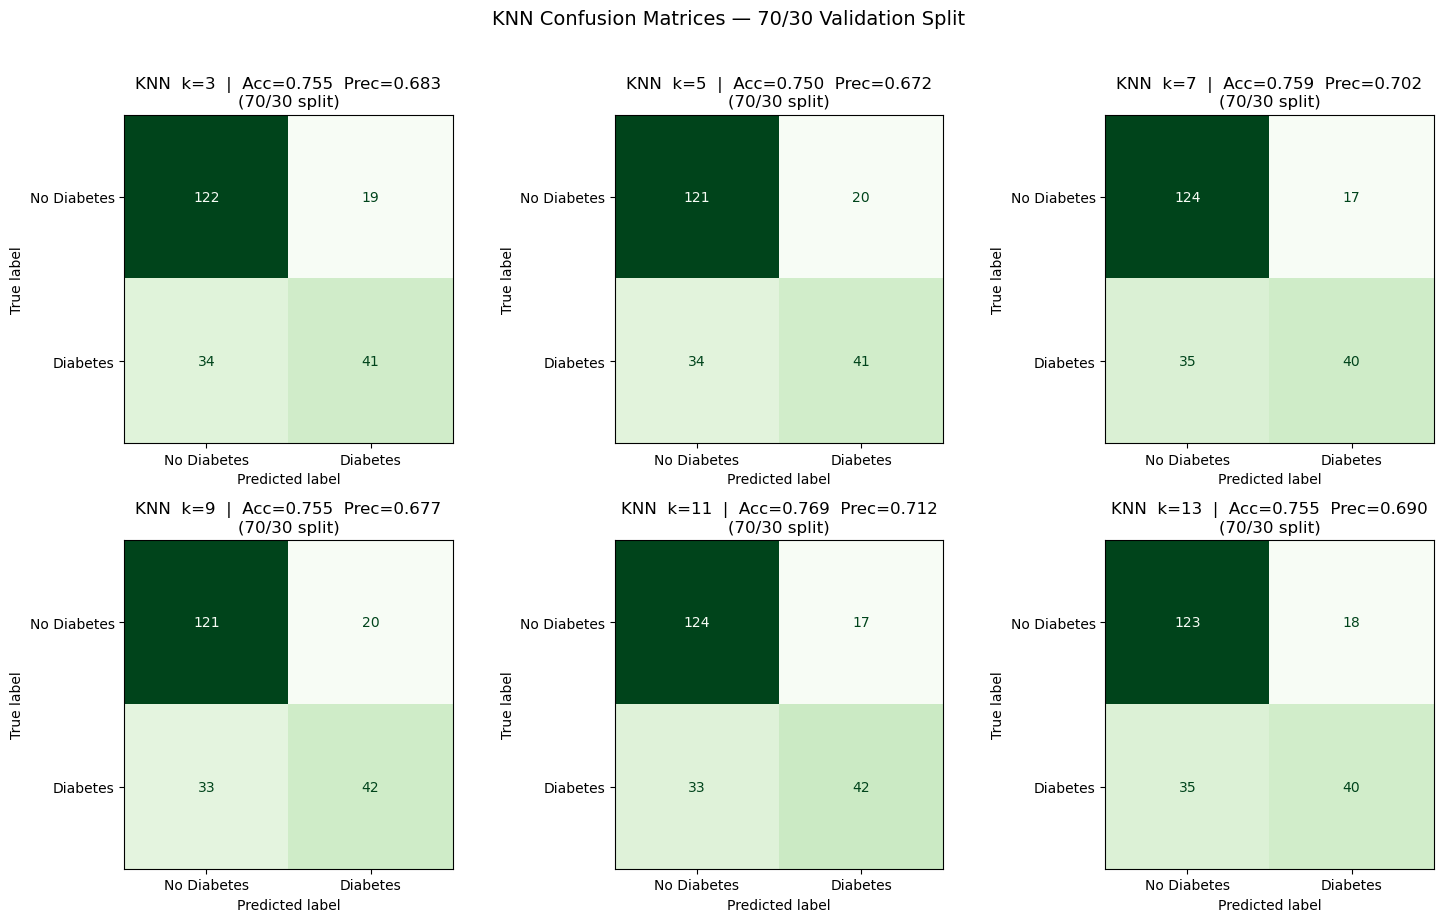

In [32]:
# Step (v): confusion matrices for k = 3,5,7,9,11,13 on the 70/30 validation split
DEMO_SPLIT = 0.70
X_tr_d, X_val_d, y_tr_d, y_val_d = split_data[DEMO_SPLIT]

scaler_d = StandardScaler()
X_tr_ds  = scaler_d.fit_transform(X_tr_d)
X_val_ds = scaler_d.transform(X_val_d)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, k in enumerate(K_VALUES):
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_tr_ds, y_tr_d)
    y_pred = knn.predict(X_val_ds)

    cm   = confusion_matrix(y_val_d, y_pred)
    acc  = accuracy_score(y_val_d, y_pred)
    prec = precision_score(y_val_d, y_pred, zero_division=0)

    disp = ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Greens')
    axes[idx].set_title(f"KNN  k={k}  |  Acc={acc:.3f}  Prec={prec:.3f}\n(70/30 split)")

plt.suptitle("KNN Confusion Matrices — 70/30 Validation Split", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
### 5.7  Step (vi) — KNN Comparison Across Splits and k Values

**Heatmaps** show accuracy and precision for every (split × k) combination.  
The **line plot** shows how accuracy evolves as k increases for each split.

What to look for:
- Accuracy typically peaks around k = 7–9 for this dataset size  
- Larger training fractions tend to give marginally higher accuracy  
- Small k (3) shows higher variance; large k (13) may underfit


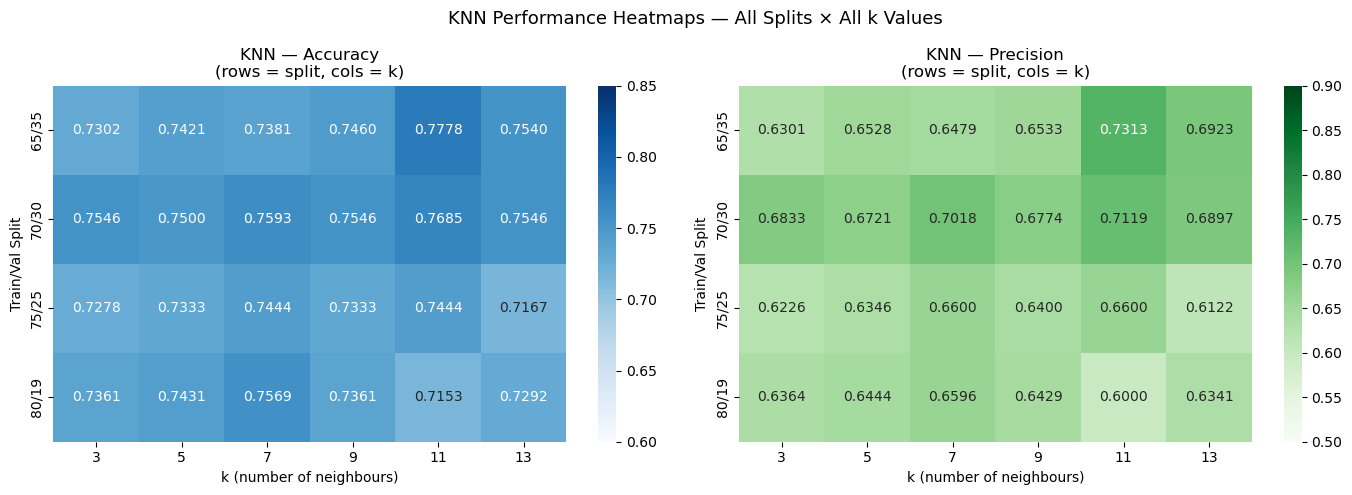

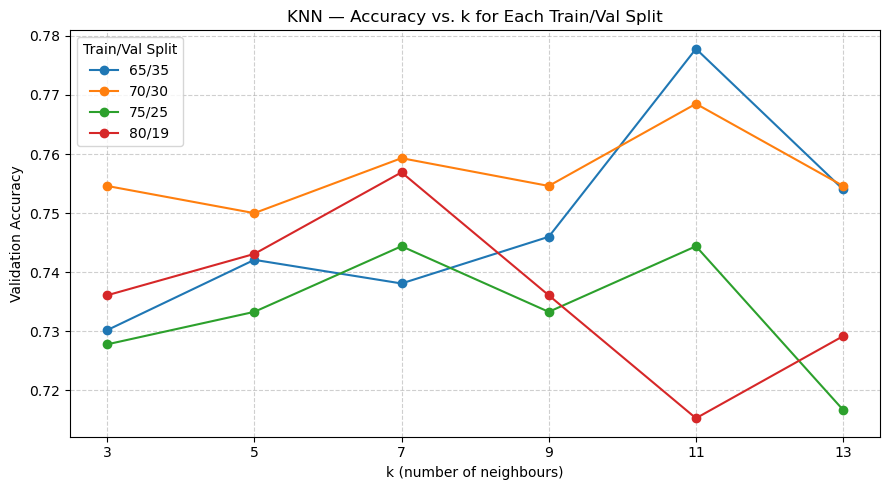

In [33]:
# Step (vi): heatmaps and line chart — KNN performance across all splits and k
acc_pivot  = knn_df.pivot(index='Split', columns='k', values='Accuracy')
prec_pivot = knn_df.pivot(index='Split', columns='k', values='Precision')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(acc_pivot,  annot=True, fmt='.4f', cmap='Blues',  ax=axes[0], vmin=0.60, vmax=0.85)
axes[0].set_title("KNN — Accuracy\n(rows = split, cols = k)")
axes[0].set_xlabel("k (number of neighbours)")
axes[0].set_ylabel("Train/Val Split")

sns.heatmap(prec_pivot, annot=True, fmt='.4f', cmap='Greens', ax=axes[1], vmin=0.50, vmax=0.90)
axes[1].set_title("KNN — Precision\n(rows = split, cols = k)")
axes[1].set_xlabel("k (number of neighbours)")
axes[1].set_ylabel("Train/Val Split")

plt.suptitle("KNN Performance Heatmaps — All Splits × All k Values", fontsize=13)
plt.tight_layout()
plt.show()

# Line plot: accuracy vs k per split
plt.figure(figsize=(9, 5))
for split_label in knn_df['Split'].unique():
    subset = knn_df[knn_df['Split'] == split_label]
    plt.plot(subset['k'], subset['Accuracy'], marker='o', label=split_label)
plt.title("KNN — Accuracy vs. k for Each Train/Val Split")
plt.xlabel("k (number of neighbours)")
plt.ylabel("Validation Accuracy")
plt.legend(title="Train/Val Split")
plt.xticks(K_VALUES)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
### 5.8  Best KNN — Final Model Evaluated on Hold-Out Test Set (n = 50)

The (split, k) combination with the **highest validation accuracy** is selected.  
That model is retrained on its training fold and applied to the **untouched 50-row  
test set** from Step (i) — giving an unbiased estimate of real-world performance.


Best KNN — Split: 65/35,  k: 11
Validation Accuracy : 0.7778
Validation Precision: 0.7313

=== Best KNN — Final Hold-Out Test Set (n=50) ===
              precision    recall  f1-score   support

 No Diabetes       0.82      0.90      0.86        31
    Diabetes       0.81      0.68      0.74        19

    accuracy                           0.82        50
   macro avg       0.82      0.79      0.80        50
weighted avg       0.82      0.82      0.82        50



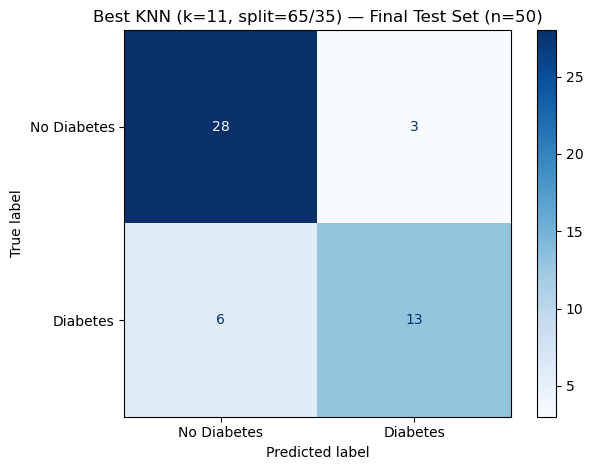

In [34]:
# Select best (split, k) by validation accuracy
best_knn_row = knn_df.loc[knn_df['Accuracy'].idxmax()]
best_split   = float(best_knn_row['Split'].split('/')[0]) / 100
best_k       = int(best_knn_row['k'])

print(f"Best KNN — Split: {best_knn_row['Split']},  k: {best_k}")
print(f"Validation Accuracy : {best_knn_row['Accuracy']}")
print(f"Validation Precision: {best_knn_row['Precision']}")

# Retrain best model, evaluate on the untouched 50-row test set
X_tr_b, _, y_tr_b, _ = split_data[best_split]
scaler_b        = StandardScaler()
X_tr_bs         = scaler_b.fit_transform(X_tr_b)          # fit on train only
X_test_final_s  = scaler_b.transform(X_test_final)        # apply same scaler to test

best_knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
best_knn.fit(X_tr_bs, y_tr_b)
y_final_pred_knn = best_knn.predict(X_test_final_s)

print("\n=== Best KNN — Final Hold-Out Test Set (n=50) ===")
print(classification_report(y_test_final, y_final_pred_knn,
                             target_names=['No Diabetes', 'Diabetes']))

cm_knn_final = confusion_matrix(y_test_final, y_final_pred_knn)
disp = ConfusionMatrixDisplay(cm_knn_final, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title(f"Best KNN (k={best_k}, split={best_knn_row['Split']}) — Final Test Set (n=50)")
plt.tight_layout()
plt.show()

#### Key Takeaway - KNN
- Overall, KNN performed best at **k = 11** with the 65/35 split, achieving a validation accuracy of 0.7778 and a final test accuracy of 0.82 on the 50-row hold-out set. 
- Accuracy was relatively stable across splits but more sensitive to k — smaller values like k = 3 introduced noise while larger values like k = 13 began to over-smooth.
- The most persistent challenge across all configurations was false negatives, meaning missed diabetes cases, which is the most clinically costly error in this context.

---
---
## Question 2 — Naïve Bayes


---
### 5.9  Steps (i–v) — Train Gaussian Naïve Bayes Across All Splits

**How Gaussian Naïve Bayes works:**  
Applies Bayes' theorem assuming features are **conditionally independent** given  
the class label, and that each feature follows a **Gaussian (normal) distribution**  
within each class.

**Strengths:** fast, interpretable, works well on small datasets.  
**Limitation:** correlated features (e.g. `skin` & `insu`: r = 0.44) can hurt  
precision because the independence assumption is violated.

The same four splits and 50-row hold-out test set from Section 5.2 are reused.  
No k-value loop applies to Naïve Bayes.


In [36]:
# Steps (i–v): train Gaussian Naïve Bayes across all four splits
nb_results = []

for train_frac, (X_tr, X_val, y_tr, y_val) in split_data.items():
    split_label = f"{int(train_frac*100)}/{int((1-train_frac)*100)}"

    # Fit scaler on training data only
    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)

    nb     = GaussianNB()
    nb.fit(X_tr_s, y_tr)
    y_pred = nb.predict(X_val_s)

    cm   = confusion_matrix(y_val, y_pred)
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)

    nb_results.append({
        'Split'    : split_label,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'TN': cm[0,0], 'FP': cm[0,1],
        'FN': cm[1,0], 'TP': cm[1,1]
    })

nb_df = pd.DataFrame(nb_results)
print("=== Naïve Bayes Validation Results ===")
nb_df

=== Naïve Bayes Validation Results ===


,Split,Accuracy,Precision,TN,FP,FN,TP
0,65/35,0.7460,0.6420,136,29,35,52
1,70/30,0.7500,0.6522,117,24,30,45
2,75/25,0.7389,0.6271,96,22,25,37
3,80/19,0.6944,0.5600,72,22,22,28


---
### 5.10  Step (v) — Confusion Matrices for Naïve Bayes (All Splits)

One matrix per split. As the training set grows, watch for changes in  
false-negative counts (missed Diabetes cases — the most clinically costly error).


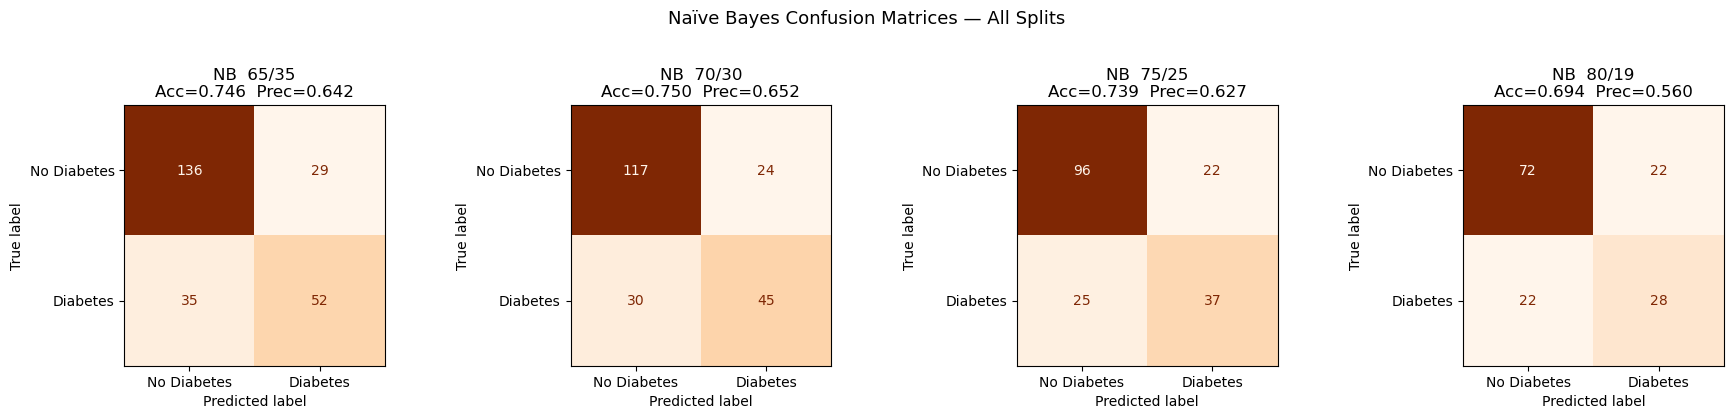

In [37]:
# Step (v): confusion matrices — one per split for Naïve Bayes
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for idx, (train_frac, (X_tr, X_val, y_tr, y_val)) in enumerate(split_data.items()):
    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)

    nb     = GaussianNB()
    nb.fit(X_tr_s, y_tr)
    y_pred = nb.predict(X_val_s)

    cm   = confusion_matrix(y_val, y_pred)
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)

    disp = ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Oranges')
    axes[idx].set_title(
        f"NB  {int(train_frac*100)}/{int((1-train_frac)*100)}\n"
        f"Acc={acc:.3f}  Prec={prec:.3f}"
    )

plt.suptitle("Naïve Bayes Confusion Matrices — All Splits", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

---
### 5.11  Step (vi) — Naïve Bayes Comparison Across Splits

As the training fraction grows the model has more data to estimate class-conditional  
Gaussian parameters, so accuracy tends to improve modestly.  
The line plot makes this trend explicit and shows precision alongside it.


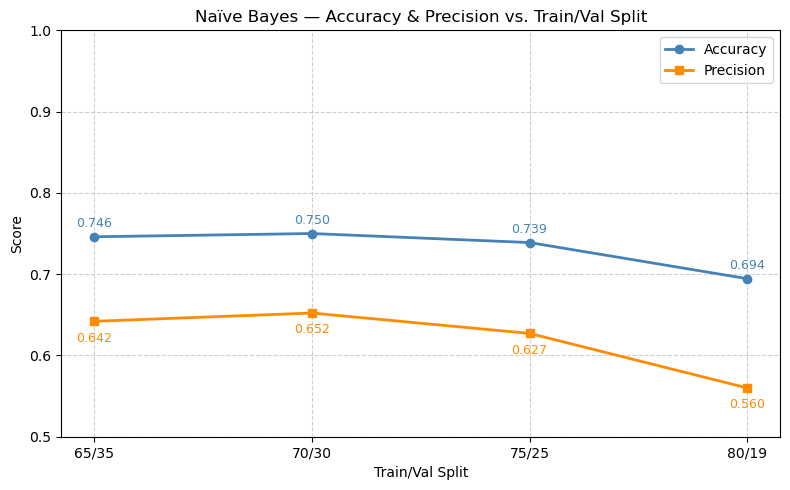

In [38]:
# Step (vi): line plot — NB accuracy & precision vs. split size
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(nb_df['Split'], nb_df['Accuracy'],
        marker='o', label='Accuracy',  color='steelblue',  linewidth=2)
ax.plot(nb_df['Split'], nb_df['Precision'],
        marker='s', label='Precision', color='darkorange', linewidth=2)

ax.set_title("Naïve Bayes — Accuracy & Precision vs. Train/Val Split")
ax.set_xlabel("Train/Val Split")
ax.set_ylabel("Score")
ax.set_ylim(0.50, 1.00)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

for i, row in nb_df.iterrows():
    ax.text(i, row['Accuracy']  + 0.012, f"{row['Accuracy']:.3f}",
            ha='center', fontsize=9, color='steelblue')
    ax.text(i, row['Precision'] - 0.025, f"{row['Precision']:.3f}",
            ha='center', fontsize=9, color='darkorange')
plt.tight_layout()
plt.show()

---
### 5.12  Best Naïve Bayes — Final Model Evaluated on Hold-Out Test Set (n = 50)

The split with the highest validation accuracy is retrained and evaluated  
on the **untouched 50-row test set** from Step (i) for an unbiased final estimate.


Best NB — Split: 70/30
Validation Accuracy : 0.75
Validation Precision: 0.6522

=== Best Naïve Bayes — Final Hold-Out Test Set (n=50) ===
              precision    recall  f1-score   support

 No Diabetes       0.74      0.84      0.79        31
    Diabetes       0.67      0.53      0.59        19

    accuracy                           0.72        50
   macro avg       0.70      0.68      0.69        50
weighted avg       0.71      0.72      0.71        50



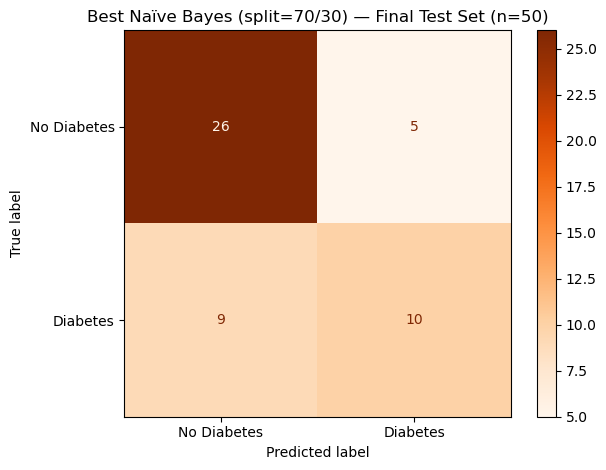

In [39]:
# Select best NB split by validation accuracy
best_nb_row   = nb_df.loc[nb_df['Accuracy'].idxmax()]
best_nb_split = float(best_nb_row['Split'].split('/')[0]) / 100

print(f"Best NB — Split: {best_nb_row['Split']}")
print(f"Validation Accuracy : {best_nb_row['Accuracy']}")
print(f"Validation Precision: {best_nb_row['Precision']}")

X_tr_nb, _, y_tr_nb, _ = split_data[best_nb_split]
scaler_nb        = StandardScaler()
X_tr_nb_s        = scaler_nb.fit_transform(X_tr_nb)       # fit on train only
X_test_final_nb  = scaler_nb.transform(X_test_final)      # apply same scaler to test

best_nb = GaussianNB()
best_nb.fit(X_tr_nb_s, y_tr_nb)
y_final_pred_nb = best_nb.predict(X_test_final_nb)

print("\n=== Best Naïve Bayes — Final Hold-Out Test Set (n=50) ===")
print(classification_report(y_test_final, y_final_pred_nb,
                             target_names=['No Diabetes', 'Diabetes']))

cm_nb_final = confusion_matrix(y_test_final, y_final_pred_nb)
disp = ConfusionMatrixDisplay(cm_nb_final, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Oranges')
plt.title(f"Best Naïve Bayes (split={best_nb_row['Split']}) — Final Test Set (n=50)")
plt.tight_layout()
plt.show()

#### Key Takeaways - Naive Bayes
- Naïve Bayes performed best on the 70/30 split with a validation accuracy of 0.750, but dropped to 0.72 on the final hold-out test. 
- Notably, accuracy did not improve as the training set grew — the 80/19 split actually produced the worst results at 0.694 accuracy and 0.560 precision.
- This is likely due to the correlated features in the dataset (skin and insu: r = 0.44), which violate the independence assumption Naïve Bayes relies on.

---
### 5.13  Combined Summary — KNN vs. Naïve Bayes (All Splits)

Side-by-side bar charts compare both algorithms across all four splits.  
KNN is shown at **k = 7** (center of the tested range) for a fair comparison.  
The full leaderboard below ranks every configuration by validation accuracy.


#### Key Takeaway - Combined Results KNN vs. NB
- KNN outperformed Naïve Bayes across all splits and metrics. At k = 7, KNN accuracy ranged from 0.738 to 0.759 versus Naïve Bayes's 0.694 to 0.750, with KNN holding all top 9 positions on the leaderboard below.
- On the final hold-out test, the gap was clear — KNN at 82% accuracy versus Naïve Bayes at 72%.
- For this dataset, KNN's ability to learn non-linear boundaries gave it a meaningful advantage over Naïve Bayes, whose core independence assumption is weakened by the moderate feature correlations present in the clinical data.

=== KNN (k=7) vs Naïve Bayes — Validation Performance ===
Split  KNN_Acc_k7  KNN_Prec_k7  NB_Acc  NB_Prec
65/35      0.7381       0.6479  0.7460   0.6420
70/30      0.7593       0.7018  0.7500   0.6522
75/25      0.7444       0.6600  0.7389   0.6271
80/19      0.7569       0.6596  0.6944   0.5600


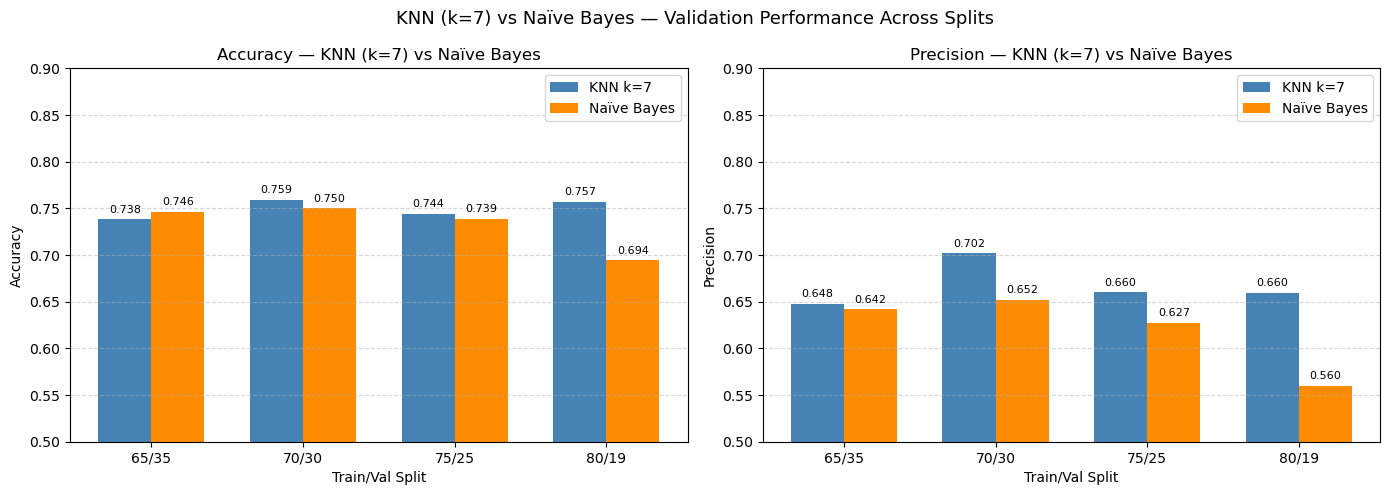

In [40]:
# Combined comparison — KNN (k=7) vs Naïve Bayes across all splits
knn_7_df = (knn_df[knn_df['k'] == 7][['Split', 'Accuracy', 'Precision']]
            .rename(columns={'Accuracy': 'KNN_Acc_k7', 'Precision': 'KNN_Prec_k7'})
            .reset_index(drop=True))

nb_sum = (nb_df[['Split', 'Accuracy', 'Precision']]
          .rename(columns={'Accuracy': 'NB_Acc', 'Precision': 'NB_Prec'})
          .reset_index(drop=True))

combined = knn_7_df.merge(nb_sum, on='Split')
print("=== KNN (k=7) vs Naïve Bayes — Validation Performance ===")
print(combined.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x     = np.arange(len(combined))
width = 0.35

for ax, knn_col, nb_col, title in [
    (axes[0], 'KNN_Acc_k7',  'NB_Acc',  'Accuracy'),
    (axes[1], 'KNN_Prec_k7', 'NB_Prec', 'Precision'),
]:
    b1 = ax.bar(x - width/2, combined[knn_col], width, label='KNN k=7',     color='steelblue')
    b2 = ax.bar(x + width/2, combined[nb_col],  width, label='Naïve Bayes', color='darkorange')
    ax.set_title(f"{title} — KNN (k=7) vs Naïve Bayes")
    ax.set_xlabel("Train/Val Split")
    ax.set_ylabel(title)
    ax.set_xticks(x)
    ax.set_xticklabels(combined['Split'])
    ax.set_ylim(0.50, 0.90)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle("KNN (k=7) vs Naïve Bayes — Validation Performance Across Splits", fontsize=13)
plt.tight_layout()
plt.show()

In [41]:
# Full leaderboard — all KNN configurations + all NB configurations
knn_board = knn_df[['Split', 'k', 'Accuracy', 'Precision']].copy()
knn_board.insert(0, 'Algorithm', knn_board['k'].apply(lambda k: f'KNN (k={k})'))
knn_board = knn_board.drop(columns='k')

nb_board = nb_df[['Split', 'Accuracy', 'Precision']].copy()
nb_board.insert(0, 'Algorithm', 'Naïve Bayes')

leaderboard = (pd.concat([knn_board, nb_board], ignore_index=True)
               .sort_values('Accuracy', ascending=False)
               .reset_index(drop=True))

print("=== Full Leaderboard — Ranked by Validation Accuracy ===")
leaderboard

=== Full Leaderboard — Ranked by Validation Accuracy ===


,Algorithm,Split,Accuracy,Precision
0,KNN (k=11),65/35,0.7778,0.7313
1,KNN (k=11),70/30,0.7685,0.7119
2,KNN (k=7),70/30,0.7593,0.7018
3,KNN (k=7),80/19,0.7569,0.6596
4,KNN (k=13),70/30,0.7546,0.6897
5,KNN (k=3),70/30,0.7546,0.6833
6,KNN (k=9),70/30,0.7546,0.6774
7,KNN (k=13),65/35,0.7540,0.6923
8,KNN (k=5),70/30,0.7500,0.6721
9,Naïve Bayes,70/30,0.7500,0.6522
